<div>
<img src="https://www.nasa.gov/wp-content/uploads/2024/07/osdr-gl4hs-logo.png" width="600"/>
</div>

# **NOTEBOOK 7: Performing gene set enrichment analysis (GSEA) and over-representation analysis (ORA)**
In this notebook, you will run statistical tests to determine which gene sets are over-represented by the differentially expressed genes you identified in the previous notebook. You'll also conduct gene set enrichment analysis which uses the gene expression data itself to determine which gene sets are enriched by genes differentially expressed between 2 groups (in this case, spaceflight and ground control).

## **Objectives of this notebook**
The primary objective of this notebook is to use Python's gseapy implementations of GSEA and ORA to find gene sets which are statistically significantly enriched by the genes that are differentially expressed between ground control and space flight groups in OSD-104.

GSEA and ORA help us better understand which biological, cellular, and molecular processes and pathways explain the phenotypic differences we may observe between space flight and ground control mice. By extension, because the mouse is a model organism with many orthologous genes to humans, we may infer how spaceflight may impact astronaut health. You can read more about GSEA in this [Wikipedia article](https://en.wikipedia.org/wiki/Gene_set_enrichment_analysis).

We use a library called enrichR which is written for R, Python, and has an [online portal](https://maayanlab.cloud/Enrichr/) you can query. You can learn more about enrichR and gene set enrichment analysis in this [YouTube video](https://www.youtube.com/watch?v=H1cUs6pql9s). The `gseapy` Python module has implementations for both GSEA as well as ORA. The major difference between these 2 approaches is that GSEA takes gene expression data as input and ORA takes a list of genes as input. As such, ORA is a more flexible tool and can be used to find gene sets and pathways that enriched by a list of genes regardless of how that list is derived. Here is a [Website](https://rnabio.org/module-08-scrna/0008/05/01/Gene_set_enrichment/) which discusses the differences between these 2 approaches.

## **UNIX commands introduced in this notebook**

N/A

# Prepare the runtime environment for the notebook

In [2]:
# mount google drive
from google.colab import drive
drive.flush_and_unmount()
drive.mount("mnt")

Drive not mounted, so nothing to flush and unmount.
Mounted at mnt


In [3]:
# time the notebook
import datetime
start_time = datetime.datetime.now()
print('notebook start time: ', start_time.strftime('%Y-%m-%d %H:%M:%S'))

notebook start time:  2025-10-14 18:02:48


In [4]:
# define OSD dataset number to use for this notebook
OSD_DATASET='678'
GLDS_DATASET='612'

In [5]:
# set DGEA_DIR to get DEGs
import os
DGEA_DIR="/content/mnt/MyDrive/NASA/GL4HS/DGEA/" + OSD_DATASET
if not os.path.exists(DGEA_DIR):
  raise Exception("STOP! You must finish the preceding notebook before running this one")

In [6]:
import os
GSEA_DIR="/content/mnt/MyDrive/NASA/GL4HS/GSEA/" + OSD_DATASET
if not os.path.exists(GSEA_DIR):
  !mkdir -p {GSEA_DIR}

In [7]:
import os
META_DIR="/content/mnt/MyDrive/NASA/GL4HS/META/" + OSD_DATASET
if not os.path.exists(META_DIR):
  raise Exception("STOP! You must finish the preceding notebook before running this one")

In [8]:
# install packages and import the modules needed to do DGEA
!pip install gseapy==1.1.8 --no-cache
import gseapy as gp
from gseapy import Msigdb
!pip install mygene

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 591.5/591.5 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 910.3 kB/s eta 0:00:00


# Define Python methods

In [9]:
# define method to run ORA
def run_ora( gene_results, gene_set_list, background_genes=[], display_cols=['Term', 'Genes', 'Adjusted P-value', 'Combined Score'], sleep_time=5, retries=10):
  counter = 0
  import time
  enr = None
  gsea = None
  while counter < retries:
    try:
      # use enrichR to get gene ontology terms for molecular function, cellular components, and biological processes
      # sometimes the call fails, so just re-run the cell after a few seconds
      enr = gp.enrichr(gene_list=list(gene_results),
                      gene_sets=gene_set_list,
                      organism='Anadoplis thaliana',
                      outdir=None,
                      )
    except:
      time.sleep(sleep_time)
      counter += 1
      continue
    break

  if not enr is None:
    # show top 10 results with adjusted p-value less than 0.05
    # other cols to display ['Term', 'Overlap', 'Genes', 'Adjusted P-value']
    gsea = enr.results[enr.results['Adjusted P-value'] < 0.05][display_cols]
  else:
    print('gsea failed')
  return gsea, enr

In [10]:
# define method to run gseapy
def run_run_ora(deg_gene_symbols, background_gene_symbols, available_gene_sets, gene_set_list):
  gene_sets = list()
  for gene_set in gene_set_list:
    if gene_set not in available_gene_sets:
      print('gene set NOT found: ', gene_set)
    else:
      print('gene set found: ', gene_set)
      gene_sets.append(gene_set)
  results, enr = run_ora(deg_gene_symbols, gene_sets, background_gene_symbols)

  return results, enr

In [11]:
# define method to convert gene ids to symbols
def get_symbols_from_ids(gene_ids):
  import mygene

  mg = mygene.MyGeneInfo()

  results = mg.querymany(gene_ids, scopes="ensembl.gene", fields="symbol", returnall=True)

  gene_symbols = list()

  # Create a dictionary to map original IDs to their symbols, handling duplicates
  symbol_map = {}
  for res in results['out']:
      original_id = res['query']
      if "symbol" in res:
          # If there are multiple symbols for the same ID, just pick the first one
          symbol_map[original_id] = res['symbol']
      else:
          # If no symbol is found, use the original ID
          symbol_map[original_id] = original_id

  # Ensure the output list has the same order and length as the input list
  for gene_id in gene_ids:
      gene_symbols.append(symbol_map.get(gene_id, gene_id)) # Use original ID if not in map

  return gene_symbols

# Read in data from google drive

In [12]:
# read DEGs from file
import os
degs = []
file_path = os.path.join(DGEA_DIR, 'deg_genes-' + OSD_DATASET + '.txt')
if not os.path.exists(file_path):
  raise Exception("STOP! You must finish the preceding notebook before running this one")
with open(file_path, 'r') as f:
  for line in f:
    degs.append(line.strip())

In [13]:
# pring the first 10 degs
print('number of DEGs: ', len(degs))
degs[:10]

number of DEGs:  133


['AT3G62950',
 'AT5G01060',
 'AT2G46790',
 'AT1G21550',
 'AT1G70820',
 'AT1G03103',
 'AT4G28520',
 'AT2G41850',
 'AT3G13061',
 'AT5G15970']

These genes are Ensembl gene IDs. You can learn more about Ensembl gene IDs [here](https://useast.ensembl.org/info/genome/stable_ids/index.html).

In [14]:
# convert gene ids to symbols and print the first 10
deg_gene_symbols = get_symbols_from_ids(degs)
deg_gene_symbols[:10]

INFO:biothings.client:querying 1-133 ...
INFO:biothings.client:Finished.


['AT3G62950',
 'BSK10',
 'PRR9',
 'AT1G21550',
 'AT1G70820',
 'AT1G03103',
 'CRU3',
 'PGAZAT',
 'AT3G13061',
 'KIN2']

These genes are Ensembl gene symbols. You can learn more about Ensembl gene naming [here](https://www.informatics.jax.org/mgihome/nomen/gene.shtml).


In [15]:
# write DEG gene symbols to file
import os
file_path = os.path.join(DGEA_DIR, 'deg_gene_symbols-' + OSD_DATASET + '.txt')
with open(file_path, 'w') as f:
  for gene in deg_gene_symbols:
    f.write(gene + '\n')

We are going to submit the list of "background" genes along with the differentially expressed genes to the gseapy Enrichr tool. You can read more about background genes on this [biostars thread](https://www.biostars.org/p/17628/).

In [16]:
# read background genes from file
background_genes = []
import os
file_path = os.path.join(DGEA_DIR, 'background_genes-' + OSD_DATASET + '.txt')
if not os.path.exists(file_path):
  raise Exception("STOP! You must finish the preceding notebook before running this one")
with open(file_path, 'r') as f:
  for line in f:
    background_genes.append(line.strip())

In [17]:
# print the first 10 background genes
print('number of background genes: ', len(background_genes))
background_genes[:10]

number of background genes:  14157


['AT1G01010',
 'AT1G01046',
 'AT1G01070',
 'AT1G01100',
 'AT1G01110',
 'AT1G01120',
 'AT1G01130',
 'AT1G01150',
 'AT1G01183',
 'AT1G01190']

In [18]:
# convert gene ids to symbols and print the first 10
background_gene_symbols = get_symbols_from_ids(background_genes)
background_gene_symbols[:10]

INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:biothings.client:querying 6001-7000 ...
INFO:biothings.client:querying 7001-8000 ...
INFO:biothings.client:querying 8001-9000 ...
INFO:biothings.client:querying 9001-10000 ...
INFO:biothings.client:querying 10001-11000 ...
INFO:biothings.client:querying 11001-12000 ...
INFO:biothings.client:querying 12001-13000 ...
INFO:biothings.client:querying 13001-14000 ...
INFO:biothings.client:querying 14001-14157 ...
INFO:biothings.client:Finished.


['NAC001',
 'MIR838',
 'UMAMIT28',
 'AT1G01100',
 'IQD18',
 'KCS1',
 'AT1G01130',
 'AT1G01150',
 'MIR165a',
 'CYP78A8']

In [19]:
# write the background gene symbols to file
with open(DGEA_DIR + '/background_gene_symbols-' + OSD_DATASET + '.txt', 'w') as f:
  for gene in background_genes:
    f.write(gene + '\n')

# Run gene set enrichment analysis
We will use gsea from the gseapy Python package to perform gene set enrichment analysis. The code in this section was drived from [this example](https://gseapy.readthedocs.io/en/latest/gseapy_example.html#GSEA-Example) in the gseapy documentation.

In [20]:
# read in expr_df from google drive
import pandas as pd
expr_df = pd.read_csv(DGEA_DIR + '/expr_df.csv')

# get list of genes from data frame
genes=list(expr_df['Unnamed: 0'])

# convert gene ids to gene symbols
gene_symbols = get_symbols_from_ids(genes)

# then cast gene names to upper case
gene_symbols_upper = [gene.upper() for gene in gene_symbols]

# Set the 'Unnamed: 0' column as the index and rename it to 'Gene'
expr_df['Unnamed: 0'] = gene_symbols_upper
expr_df = expr_df.set_index('Unnamed: 0')
expr_df.index.name = 'Gene'

# Handle duplicate gene names by keeping the first occurrence
expr_df = expr_df[~expr_df.index.duplicated(keep='first')]

# print first 5 rows of expression matrix
display(expr_df.head())

INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:biothings.client:querying 6001-7000 ...
INFO:biothings.client:querying 7001-8000 ...
INFO:biothings.client:querying 8001-9000 ...
INFO:biothings.client:querying 9001-10000 ...
INFO:biothings.client:querying 10001-11000 ...
INFO:biothings.client:querying 11001-12000 ...
INFO:biothings.client:querying 12001-13000 ...
INFO:biothings.client:querying 13001-14000 ...
INFO:biothings.client:querying 14001-14157 ...
INFO:biothings.client:Finished.


,Flight_Col-0_Dark_bio_rep1,Flight_Col-0_Dark_bio_rep2,Flight_Col-0_Dark_bio_rep3,Flight_Col-0_Light_bio_rep1,Flight_Col-0_Light_bio_rep2,Flight_Col-0_Light_bio_rep3,Flight_Ws_Dark_bio_rep1,Flight_Ws_Dark_bio_rep2,Flight_Ws_Dark_bio_rep3,Flight_Ws_Light_bio_rep1,...,Ground_control_Ws_Dark_bio_rep3,Ground_control_Ws_Light_bio_rep1,Ground_control_Ws_Light_bio_rep2,Ground_control_Ws_Light_bio_rep3,Ground_control_phyD_Dark_bio_rep1,Ground_control_phyD_Dark_bio_rep2,Ground_control_phyD_Dark_bio_rep3,Ground_control_phyD_Light_bio_rep1,Ground_control_phyD_Light_bio_rep2,Ground_control_phyD_Light_bio_rep3
Gene,,,,,,,,,,,,,,,,,,,,,
NAC001,1383,1793,450,507,890,1507,1854,2483,3317,3618,...,2519,121,94,193,2172,1751,1305,332,187,174
MIR838,0,0,15,0,6,0,1,2,11,18,...,5,2,0,5,0,0,12,0,0,0
UMAMIT28,588,679,66,277,275,437,374,583,653,44,...,1093,117,99,101,882,782,413,169,122,101
AT1G01100,17572,16359,6179,11831,12493,18503,18092,41365,37079,10419,...,17800,7866,4828,10586,16459,14773,15858,10577,8858,9265
IQD18,1159,979,168,184,258,326,985,1236,1864,193,...,849,196,208,286,1018,1058,1357,782,499,558


Note that the column containing the genes is called `Unnamed: 0`. This is a name given by the pandas library to the first column in a column-separated or tab-separated value file which doesn't have a name.

In [21]:
# get metadata from file that was written in previous notebook

import pandas as pd
meta_df = pd.read_csv(f"{META_DIR}/s_OSD-" + OSD_DATASET + ".txt", sep='\t')

# create list of classes for samples
classes = list(meta_df['Factor Value[Spaceflight]'])
print(classes[:10])

['Ground Control', 'Ground Control', 'Ground Control', 'Ground Control', 'Ground Control', 'Ground Control', 'Space Flight', 'Space Flight', 'Space Flight', 'Space Flight']


There should be 6 samples from the `Ground Control` group and 6 samples from the `Space Flight` group.

In [39]:
import os
import gseapy as gp
import pandas as pd

# ------------------------------
# 1️⃣ Load log2FC data with TAIR IDs
# ------------------------------
# Assuming expr_df is already loaded and contains the expression data with TAIR IDs as index
# If not, you may need to load it here:
# expr_df = pd.read_csv(os.path.join(DGEA_DIR, 'expr_df.csv'), index_col=0)

# Convert to a ranked series: gene -> log2FC
# Assuming the first column after the index contains the log2FC or a value to rank by
# You might need to adjust the column selection based on your specific expr_df structure
if 'expr_df' not in locals():
    raise Exception("STOP! expr_df not found. Please run the cell loading and processing expr_df first.")

# Assuming the first data column (index 0 after the index column) is what you want to rank
# Replace '0' with the correct column index or name if necessary
ranked_gene_list = expr_df.iloc[:, 0]
ranked_gene_list = ranked_gene_list.sort_values(ascending=False)

# Save as a .rnk file (optional, gseapy prefers this format)
rnk_file = os.path.join(DGEA_DIR, 'log2FC_ranked.rnk')
ranked_gene_list.to_csv(rnk_file, sep='\t', header=False)

# ------------------------------
# 2️⃣ Run prerank GSEA
# ------------------------------
# Assuming Arabidopsis_GO.gmt is in the DGEA_DIR and contains TAIR IDs
gmt_file = os.path.join(DGEA_DIR, "Arabidopsis_GO.gmt")
if not os.path.exists(gmt_file):
     raise Exception(f"STOP! GMT file not found at {gmt_file}. Please ensure it's in the correct directory.")

prerank_res = gp.prerank(
    rnk=rnk_file,        # ranked gene list file
    gene_sets=gmt_file,  # GMT file with TAIR IDs
    outdir=None,
    min_size=10,
    max_size=500,
    permutation_num=0,    # 0 because no permutations are possible for prerank
    threads=2,
    seed=7
)

# ------------------------------
# 3️⃣ Extract top pathways by NES
# ------------------------------
results_df = prerank_res.res2d

# Check available columns in results_df
print("Available columns in GSEA results:", results_df.columns.tolist())


# Define display columns based on available columns
# Based on previous output, these columns are expected to be present
display_cols = ['Name', 'Term', 'ES', 'NES']


# Sort by absolute NES to see strongest trends
top_trends = results_df.sort_values(by='NES', key=abs, ascending=False)

# Select relevant columns
print("\nTop trending GO terms (NES only, no p-values):")
display(top_trends[display_cols].head(10))

# Optionally save to CSV
output_file = os.path.join(GSEA_DIR, f'prerank_top_trends_{OSD_DATASET}.csv')
top_trends.to_csv(output_file, index=False)
print("\nTop trending GO terms saved:", output_file)

2025-10-14 18:48:09,859 [WARNING] Duplicated values found in preranked stats: 77.45% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Available columns in GSEA results: ['Name', 'Term', 'ES', 'NES']

Top trending GO terms (NES only, no p-values):


,Term,NES,ES
0,GO:0000082,0.0,0.609973
536,GO:0046910,0.0,0.769919
514,GO:0080092,0.0,0.866086
515,GO:0016298,0.0,0.669064
516,GO:0045595,0.0,0.656248
517,GO:0000145,0.0,0.699746
518,GO:1990961,0.0,0.502223
519,GO:0009853,0.0,0.925725
520,GO:0020037,0.0,0.642106
521,GO:0008066,0.0,0.433963



Top trending GO terms saved: /content/mnt/MyDrive/NASA/GL4HS/DGEA/678/GSEA_results/prerank_top_trends_678.csv


There are 3 gene ontology (GO) gene sets in the database, and we're querying all of them. We're passing the `expr_df` expression matrix, list of GO gene sets, and the classes (FLT vs GC) to the `gsea()` method. We are keeping only those results with a family-wise error rate (FWER) p-value less than 0.05. FWER is another technique alongside Benjamini-Hochberg and Bonferroni for adjusting p-values to correct for the multiple-testing problem. You can read more about FWER in [this Wikipedia article](https://en.wikipedia.org/wiki/Family-wise_error_rate).

Note in this case, while we requested the top 10 rows of the results, we only got 3 which indicates that only 3 gene sets were enriched with a FWER-adjusted p-value less than 0.05.

In [23]:
# plot GO GSEA results in dot plot
from gseapy import dotplot
import matplotlib.pyplot as plt

if not go_gsea_results.empty:
    ax = dotplot(go_gsea_results,
                 column="FWER p-val",
                 title='GO GSEA',
                 cmap=plt.cm.viridis,
                 size=5,
                 figsize=(4,5), cutoff = 1)
    plt.show()
else:
    print("No significant GO terms found to plot.")

No significant GO terms found to plot.


The smaller the FWER p-value, the more significant the statistical enrichment. The higher the percentage of genes in the gene set, the larger the dot in the plot. The horizontal axis is the normalized enrichment score (NES).

In [24]:
# plot GO GSEA results in heatmap
from gseapy import heatmap
terms = go_gsea_results.Term

for i in range(len(go_gsea_results)):
  genes = go_gsea_results.Lead_genes[i].split(";")
  ax = heatmap(df = go_gsea_res.heatmat.loc[genes], z_score=0, title=terms[i], figsize=(14,4))

This heatmap uses colors from blue ("cold") to red ("hot"), where cold implies low gene expression and hot implies high gene expression. The difference between the FLT and GC samples is very evident in the plot.

In [25]:
geo_gene_sets = ['Disease_Perturbations_from_GEO_down', \
                 'Disease_Perturbations_from_GEO_up']

geo_gsea_res = gp.gsea(data=expr_df,
                 gene_sets=geo_gene_sets,
                 cls= classes,
                 # set permutation_type to phenotype if samples >=15
                 outdir=None,
                 method='signal_to_noise',
                 threads=2, seed= 7)

# filter results based on FWER p-val
geo_gsea_results = geo_gsea_res.res2d[geo_gsea_res.res2d['FWER p-val'] < 0.1]

# define columns to display in output
display_cols = ['Term', 'Lead_genes', 'NES', 'FWER p-val']

# print top 10 GSEA results
geo_gsea_results[display_cols].head(10)

# save the GEO GSEA results to google drive
geo_gsea_results.to_csv(GSEA_DIR + '/geo_gsea_results_' + OSD_DATASET + '.csv', index=None)

There are 2 gene expression omnibus (GEO) gene sets in the database, and we're querying both of them. We're passing the `expr_df` expression matrix, list of GEO gene sets, and the classes (FLT vs GC) to the `gsea()` method.  The normalized enrichment score (NES) is the de facto metric to use when sorting results, all of which are statistically significant with FWER p-values less than 0.05. You can read more about the normalized enrichment score [here](https://www.gsea-msigdb.org/gsea/doc/GSEAUserGuideTEXT.htm#_Normalized_Enrichment_Score).

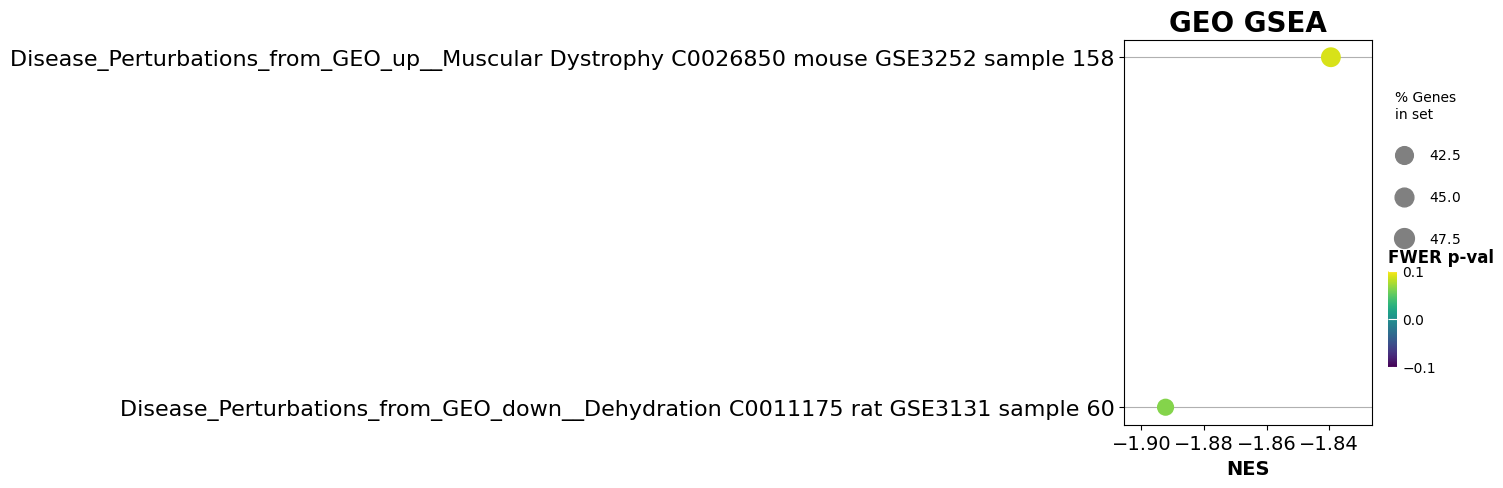

In [26]:
# create the dot plot
from gseapy import dotplot
import matplotlib.pyplot as plt

if not geo_gsea_results.empty:
    ax = dotplot(geo_gsea_results,
                 column="FWER p-val",
                 title='GEO GSEA',
                 cmap=plt.cm.viridis,
                 size=5,
                 figsize=(4,5), cutoff = 1)
    plt.show()
else:
    print("No significant GEO terms found to plot.")

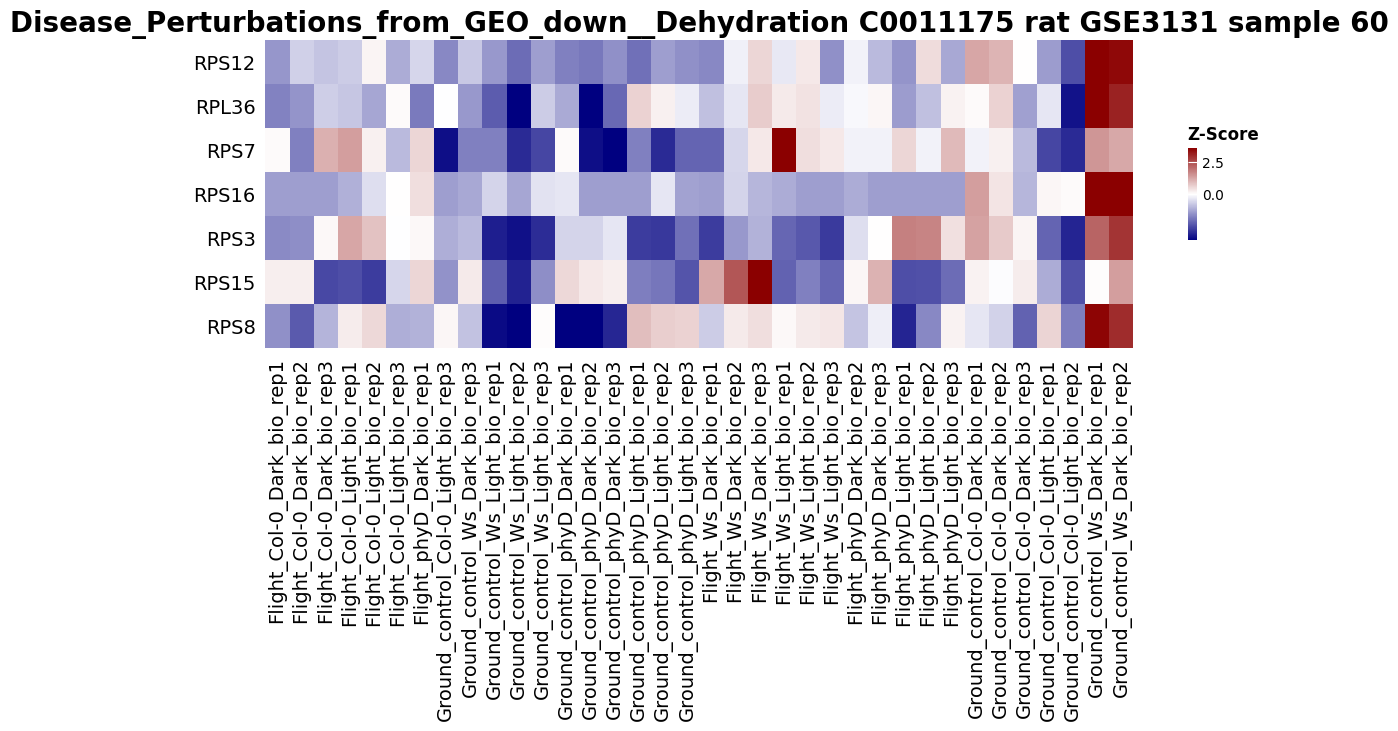

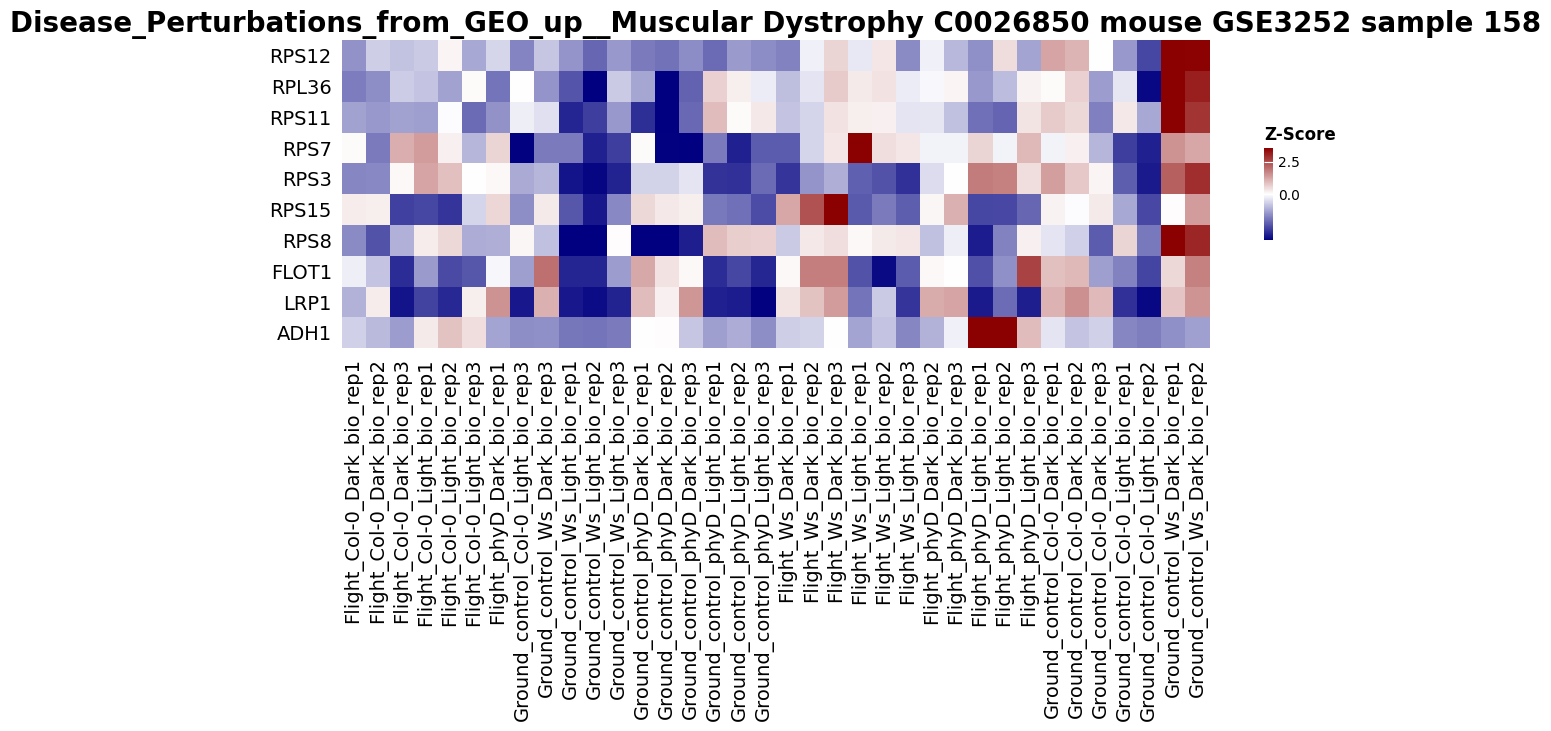

In [27]:
# plot GEO GSEA results in heatmap
from gseapy import heatmap
terms = geo_gsea_results.Term

for i in range(len(geo_gsea_results)):
  genes = geo_gsea_results.Lead_genes[i].split(";")
  ax = heatmap(df = geo_gsea_res.heatmat.loc[genes], z_score=0, title=terms[i], figsize=(14,4))

# Run over-representation analysis

We will use Enrichr from the `gseapy` Python package to perform over-representation analysis. You can learn more about Enrichr [here](https://bmcbioinformatics.biomedcentral.com/articles/10.1186/1471-2105-14-128).

          GO_ID Pathway_Name  \
74   GO:0006970                
93   GO:0009269                
97   GO:0009409                
98   GO:0009414                
120  GO:0009737                

                                                 Genes  Adjusted P-value  \
74   AT1G43160;AT5G52310;AT5G06760;AT5G15970;AT1G32...          0.000016   
93                       AT2G33380;AT5G52310;AT1G01470          0.037431   
97   AT5G58784;AT1G43160;AT5G52310;AT2G33380;AT5G06...          0.001536   
98   AT3G02480;AT1G43160;AT5G52310;AT1G52890;AT5G06...          0.000016   
120  AT1G43160;AT5G52310;AT4G28520;AT2G33380;AT5G15...          0.002029   

     Combined Score                                   QuickGO_Link  
74       238.358858  https://www.ebi.ac.uk/QuickGO/term/GO:0006970  
93       165.295662  https://www.ebi.ac.uk/QuickGO/term/GO:0009269  
97        68.418720  https://www.ebi.ac.uk/QuickGO/term/GO:0009409  
98       121.216087  https://www.ebi.ac.uk/QuickGO/term/GO:0009414  
120  

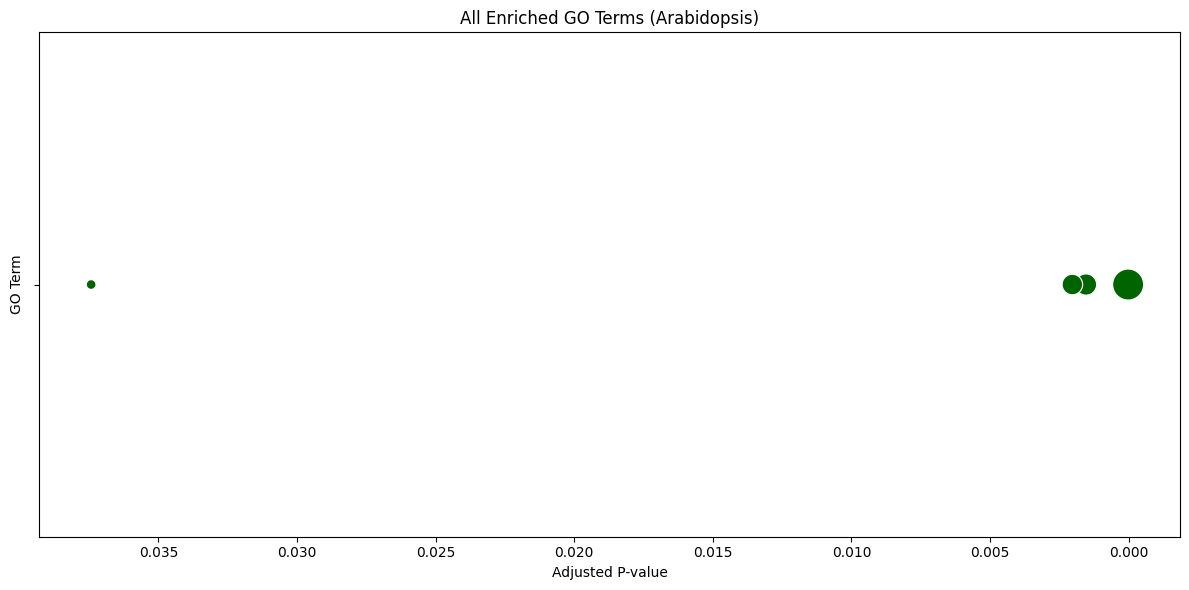

In [28]:
import gseapy as gp
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Paths to your files
gmt_file = os.path.join(DGEA_DIR, "Arabidopsis_GO.gmt")
deg_file = os.path.join(DGEA_DIR, f'deg_genes-{OSD_DATASET}.txt')  # DEGs
background_file = os.path.join(DGEA_DIR, f'background_genes-{OSD_DATASET}.txt')  # all genes

# Read DEGs and background genes
with open(deg_file) as f:
    deg_genes = [line.strip() for line in f if line.strip()]

with open(background_file) as f:
    background_genes = [line.strip() for line in f if line.strip()]

# Run ORA with local GMT file
enr = gp.enrichr(
    gene_list=deg_genes,
    gene_sets=gmt_file,
    background=background_genes,
    outdir=None
)

# Filter by adjusted p-value < 0.05
ora_results = enr.results[enr.results['Adjusted P-value'] < 0.05].copy()

# Ensure 'Term' is string and split GO ID and pathway name
ora_results['Term'] = ora_results['Term'].astype(str)

def split_go_term(term):
    parts = term.split(' ', 1)
    go_id = parts[0]
    name = parts[1] if len(parts) > 1 else ''
    return pd.Series([go_id, name])

ora_results[['GO_ID', 'Pathway_Name']] = ora_results['Term'].apply(split_go_term)

# Add QuickGO link
ora_results['QuickGO_Link'] = ora_results['GO_ID'].apply(
    lambda x: f"https://www.ebi.ac.uk/QuickGO/term/{x}"
)

# Reorder columns for clarity
display_cols = ['GO_ID', 'Pathway_Name', 'Genes', 'Adjusted P-value', 'Combined Score', 'QuickGO_Link']
ora_results = ora_results[display_cols]

# Display all ORA results
print(ora_results)

# Save results
ora_results.to_csv(os.path.join(GSEA_DIR, f'ora_results_Arabidopsis_{OSD_DATASET}.csv'), index=False)

# Plot all ORA results as dot plot
if not ora_results.empty:
    plot_data = ora_results.copy()
    plot_data['Significance'] = -np.log10(plot_data['Adjusted P-value'])

    plt.figure(figsize=(12, max(6, 0.3*len(plot_data))))
    sns.scatterplot(
        x='Adjusted P-value',
        y='Pathway_Name',
        size='Significance',
        sizes=(50, 500),
        data=plot_data,
        color='darkgreen',
        legend=False
    )
    plt.title('All Enriched GO Terms (Arabidopsis)')
    plt.xlabel('Adjusted P-value')
    plt.ylabel('GO Term')
    plt.gca().invert_xaxis()  # smaller p-values to top
    plt.tight_layout()
    plt.show()
else:
    print("No significant GO terms found to plot.")


In [29]:
# print libraries out
mouse_libraries = gp.get_library_name(organism='Anadoplis thaliana')
print('all libraries: ', mouse_libraries)


LookupError: No supported database. Please input one of these:
                            ('Human', 'Mouse', 'Yeast', 'Fly', 'Fish', 'Worm') 

We are only going to look at a few of those gene sets, but you should feel free to add more gene sets from the list above to the list below. You can learn more about these gene sets [here](https://maayanlab.cloud/Enrichr/#libraries).

In [ ]:
# verify the gene sets we're exploring are still part of the supported libraries
# if one is not available, terminate the notebook!
available_gene_sets = list()

for gene_set in ['GO_Molecular_Function_2025', \
                 'GO_Biological_Process_2025', \
                 'GO_Cellular_Component_2025', \
                 'Disease_Perturbations_from_GEO_down', \
                 'Disease_Perturbations_from_GEO_up']:
  if gene_set not in list_of_gene_sets:
    print('gene set not found!:', gene_set)
    raise Exception("STOP! remove this gene set from the gene_set list above as it appears to be unavailable")
  else:
    print('gene set found: ', gene_set)
    available_gene_sets.append(gene_set)

In [ ]:
# define dictionary to hold results and enrichR object to hold enrichR data
enrichr_results = {}
enrichr = {}

**NOTE**

The calls to the online Enrichr Web Service may fail (it's a free Web service that has been known to periodically fail). If they do fail, you can copy the list of differentially expressed genes into your favorite editor (like MS Word or textedit or Google Docs) and create a list such as the following by removing the "'", "[", "]" characters from the list. Then use online pathway and gene set enrichment tools such as [DAVID](https://davidbioinformatics.nih.gov/summary.jsp), [MSigDB](https://www.gsea-msigdb.org/gsea/login.jsp), and [ShinyGO](https://bioinformatics.sdstate.edu/go/).



In [ ]:
# Get GO results
# print the top 10
gene_sets = ['GO_Molecular_Function_2025','GO_Cellular_Component_2025', 'GO_Biological_Process_2025']
enrichr_results['GO'], enrichr['GO'] = run_run_ora(deg_gene_symbols, background_gene_symbols, available_gene_sets, gene_sets)
enrichr_results['GO'].head(10)


The output includes each of the gene ontologies that are over-represented by your list of significantly differentially expressed genes. The ORA output is sorted by adjusted p-value.

Each over-represented gene set includes your genes which belong to that gene set, along with the adjusted p-value representing the significance of the enrichment. Recall that, in DGEA where we are conducting the same statistical test thousands of times, we needed to adjust the p-value to account for the inflated number of false positives due to multiple testing. Similarly, here we are also conducting the same statistical test thousands of times -- once per gene set. So we also need to adjust the p-value accordingly. You can learn more about how p-values are calculated and adjusted in this [YouTube video](https://www.youtube.com/watch?v=EF94wPaqXM0).

You can learn more about GO (gene ontology) and the 3 aspects Molecular Function (MF), Cellular Component (CC), and Biological Process (BP) in [this document](https://geneontology.org/docs/ontology-documentation/).

In [ ]:
# get disease perturbations for down-regulated GEO signatures
# print the top 10
gene_sets = ['Disease_Perturbations_from_GEO_down']
enrichr_results['GEO_down'], enrichr['GEO_down'] = run_run_ora(deg_gene_symbols, background_gene_symbols, available_gene_sets, gene_sets)
enrichr_results['GEO_down'].head(10)


Here we see 16 different gene sets over-represented by our list of differentially expressed genes. All adjusted p-values are necessarily less than 0.05 because the alpha threshold of significance in our `run_ora()` method defined it as such. If we were to relax this threshold, we should anticipate finding more over-represented gene sets. Similarly, if we were to lower this threshold, we should anticipate finding fewer over-represented gene sets.



In [ ]:
# examine the full term and list of genes for the first enriched gene set in the GEO_down library.
if not enrichr_results['GEO_down'].empty:
    print('GEO_down term: ', enrichr_results['GEO_down'].iloc[0]['Term'])
    print('GEO_down genes: ', enrichr_results['GEO_down'].iloc[0]['Genes'])
else:
    print("No significant terms found for Disease_Perturbations_from_GEO_down.")

You can learn more about spinal muscular atrophy in this [research article](https://www.sciencedirect.com/science/article/pii/S0925443914002440). You can learn more about each of the genes using the online NCBI tool called [entrez-gene](https://www.ncbi.nlm.nih.gov/gene/). For example, you can use entrez-gene to learn more about the SLC13A1 gene [here](https://www.ncbi.nlm.nih.gov/gene/55961).

From the list of genes that are over-represented in this gene set, 3 of them are prefixed SLC (solute carrier family of genes). You can learn more about solute carriers in this short [YouTube video](https://www.youtube.com/watch?v=clbvOvQvq5U).

There has been other research that found differentially expressed solute carrier gene expression in spaceflown mice (e.g. [this article](https://pmc.ncbi.nlm.nih.gov/articles/PMC2644242/)).

In [ ]:
# get disease perturbations for up-regulated GEO signatures
# print the top 10
gene_sets = ['Disease_Perturbations_from_GEO_up']
enrichr_results['GEO_up'], enrichr['GEO_up'] = run_run_ora(deg_gene_symbols, background_gene_symbols, available_gene_sets, gene_sets)
enrichr_results['GEO_up'].head(10)


In [ ]:
# examine the full term and list of genes for the first enriched gene set of the GEO_up library
if not enrichr_results['GEO_up'].empty:
    print('GEO_up term: ', enrichr_results['GEO_up'].iloc[0]['Term'])
    print('GEO_up genes: ', enrichr_results['GEO_up'].iloc[0]['Genes'])
else:
    print("No significant terms found for Disease_Perturbations_from_GEO_up.")

This particular gene set (idiopathic pulmonary fibrosis) doesn't seem to have much in common with our tissue (soleus muscle) or the condition of spaceflight. Sometimes this happens. The p-value represents the probability of making this observation (identifying disease perturbation gene set enrichment) by random chance. This probability / p-value is never 0 and therefore is one reason you may well observe false positives. Another reason is that gene sets have overlapping genes because genes may participate in multiple unrelated biological and molecular pathways.

Even so, there may be an association between the over-represented gene set and the phenotype you're observing. In this particular case, pulmonary fibrosis may lead to musculoskeletal pathology (see this [article](https://pmc.ncbi.nlm.nih.gov/articles/PMC10851557/)) which is itself a hallmark risk of spaceflight for vertebrate animals such as humans and mice. We may then speculate that genes which differentially respond to the effects of pulmonary fibrosis may also respond to the effects of spaceflight.

So after getting these results, you may need to further filter out the gene sets that do not correspond to the tissue and phenotype in your experiment. How to interpret ORA results is discussed in the [GSEA documentation](https://www.gsea-msigdb.org/gsea/doc/GSEAUserGuideFrame.html).

In general, it's important to note that the results from GSEA and ORA identify genes which are *associated* with a disease or molecular or biological process, not necessarily *causal* of any outcomes. Combining multiple forms of this type of analysis can help refine your results as discussed in [this YouTube video](https://www.youtube.com/watch?v=t90x9TlW6Y0). As such, GSEA and ORA are hypothesis generators and you need to be careful with how you interpret the results.

In [ ]:
# save results to file
for db in enrichr_results.keys():
  if not enrichr_results[db] is None:
    enrichr_results[db].to_csv(GSEA_DIR + '/ora_results_' + db + '_' + OSD_DATASET + '.csv', index=None)

# Plot ORA results
A GO plot is used to visualize the enriched Gene Ontology (GO) terms generated from the previous steps of the notebook. The four plots generated below represent two of the same results in two slightly visual formats (dot plot versus lollipop plot): In both the dot plot and the lollipop plot, the size of the marker represents the significance of the over-representation (based on the adjusted p-value), while the position along the x-axis indicates the adjusted p-value itself, with smaller values (higher significance) appearing further to the right.  If a process is "significantly over-represented", this indicates that the set of genes is likely contributing to the differences between ground control and space flight factors.

In [ ]:
# Plot top GO terms as dot plot with size representing significance

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if not enrichr_results['GO'].empty:
    # Add a column for plotting size based on -log10(Adjusted P-value)
    plot_data = enrichr['GO'].res2d.head(10).copy()
    plot_data['Significance'] = -np.log10(plot_data['Adjusted P-value'])

    plt.figure(figsize=(10, 8))
    sns.scatterplot(x='Adjusted P-value', y='Term', size='Significance', sizes=(100, 1000), \
                    data=plot_data, color='darkblue', legend=False) # sizes sets the range of dot sizes
    plt.title('Top 10 Enriched GO Terms (Size based on Significance)')
    plt.xlabel('Adjusted P-value')
    plt.ylabel('GO Term')
    plt.gca().invert_xaxis() # Invert x-axis to show smaller p-values at the top
    plt.show()
else:
    print("No significant GO terms found to plot.")

In [ ]:
# Plot top GEO up and down terms as dot plot with size representing significance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

geo_results = pd.concat([enrichr_results['GEO_down'], enrichr_results['GEO_up']], ignore_index=True)

if not geo_results.empty:
    # Add a column for plotting size based on -log10(Adjusted P-value)
    plot_data = enrichr['GEO_down'].res2d.head(10).copy()
    plot_data['Significance'] = -np.log10(plot_data['Adjusted P-value'])

    plt.figure(figsize=(12, 10))
    sns.scatterplot(x='Adjusted P-value', y='Term', size='Significance', sizes=(100, 1000), \
                    data=plot_data, color='darkblue', legend=False) # sizes sets the range of dot sizes
    plt.title('Top 10 Enriched GEO Perturbation Signatures (Size based on Significance)')
    plt.xlabel('Adjusted P-value')
    plt.ylabel('GEO Term')
    plt.gca().invert_xaxis() # Invert x-axis to show smaller p-values at the top
    plt.show()
else:
    print("No significant GEO terms found to plot.")

In [ ]:
# create lollipop plots for GO ORA results
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if not enrichr_results['GO'].empty:
    '''plot_data = enrichr_results['GO'].head(10).copy()
    plot_data['Significance'] = -np.log10(plot_data['Adjusted P-value'])'''
    plot_data = enrichr['GO'].res2d.head(10).copy()
    plot_data['Significance'] = -np.log10(plot_data['Adjusted P-value'])
    plot_data = plot_data.sort_values('Adjusted P-value', ascending=True) # Sort for better visualization

    plt.figure(figsize=(10, 8))
    plt.hlines(y=plot_data['Term'], xmin=0, xmax=plot_data['Adjusted P-value'], color='skyblue')

    # Plot each point individually with its corresponding marker size
    for index, row in plot_data.iterrows():
        plt.plot(row['Adjusted P-value'], row['Term'], "o", markersize=row['Significance'] * 2, color='darkblue')

    plt.title('Top 10 Enriched GO Terms (Size based on Significance)')
    plt.xlabel('Adjusted P-value')
    plt.ylabel('GO Term')
    plt.gca().invert_xaxis() # Invert x-axis to show smaller p-values at the top
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("No significant GO terms found to plot.")

In [ ]:
# create lollipop plots for GEO ORA results
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

geo_results = pd.concat([enrichr_results['GEO_down'], enrichr_results['GEO_up']], ignore_index=True)

if not geo_results.empty:
    plot_data = geo_results.head(10).copy()
    plot_data['Significance'] = -np.log10(plot_data['Adjusted P-value'])
    plot_data = plot_data.sort_values('Adjusted P-value', ascending=True) # Sort for better visualization

    plt.figure(figsize=(12, 10))
    plt.hlines(y=plot_data['Term'], xmin=0, xmax=plot_data['Adjusted P-value'], color='skyblue')

    # Plot each point individually with its corresponding marker size
    for index, row in plot_data.iterrows():
        plt.plot(row['Adjusted P-value'], row['Term'], "o", markersize=row['Significance'] * 2, color='darkblue')

    plt.title('Top 10 Enriched GEO Perturbation Signatures (Size based on Significance)')
    plt.xlabel('Adjusted P-value')
    plt.ylabel('GEO Term')
    plt.gca().invert_xaxis() # Invert x-axis to show smaller p-values at the top
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("No significant GEO terms found to plot.")

# Verify notebook is complete before moving on

In [ ]:
# make sure your google drive disk space utilization is still under 15G
# should be about 2.4GB
!du -sh /content/mnt/MyDrive/NASA/GL4HS

In [ ]:
# time the notebook
import datetime
end_time = datetime.datetime.now()
print('notebook end time: ', end_time.strftime('%Y-%m-%d %H:%M:%S'))

print('notebook runtime: ', end_time - start_time)

In [ ]:
# make sure your google drive disk space utilization is still under 15G
# should be about 2.4GB
!du -sh /content/mnt/MyDrive/NASA/GL4HS

In [ ]:
# Display the full GEO GSEA results before filtering
if 'geo_gsea_res' in locals():
    display(geo_gsea_res.res2d)
else:
    print("GEO GSEA results not available. Please run the GSEA analysis cell first.")